# AI Heat Resilience Hackathon — Pipeline v3
## RGB-Primary Architecture with Pretrained ResNet34

**Key improvements over v2:**
- Pretrained ResNet34 encoder (already knows buildings, roads, textures from ImageNet)
- RGB image is PRIMARY input (correct drone structure)
- ThermalGen output is just a secondary hint
- Data augmentation (flips, rotations) to stretch 418 samples
- Perceptual loss (VGG) for sharper, more realistic output

**Run cells in order. Phase 1 is already done — skip to Phase 2.**

## Cell 1: Setup & Paths

In [1]:
import os, json, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as v2
import torchvision.transforms.functional as TF
from torchvision.transforms.functional import to_pil_image
from torchvision import models
from PIL import Image
from pathlib import Path
from IPython.display import display, Image as IPImage

# Set device — use GPU 1 (GPU 0 is busy)
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Paths
BASE = Path(os.path.expanduser('~/AI_Heat_Resilience_Hackathon_Resources/AI_Heat_Resilience_Hackathon_Resources'))
THERMAL_GEN_DIR = BASE / 'ThermalGen'

TRAIN_RGB_DIR = THERMAL_GEN_DIR / 'datasets_raw' / 'Train_2' / 'RGB'
TRAIN_THERMAL_DIR = THERMAL_GEN_DIR / 'datasets_raw' / 'Train_2' / 'Thermal'
TEST_RGB_DIR = THERMAL_GEN_DIR / 'datasets_raw' / 'Test_2' / 'RGB'

BASELINE_PRED_TRAIN = THERMAL_GEN_DIR / 'baseline_predictions' / 'train'
BASELINE_PRED_TEST = THERMAL_GEN_DIR / 'baseline_predictions' / 'test'

SPLIT_JSON = BASE / 'train_test_split.json'
WEATHER_JSON = BASE / 'Weather_data_and_code' / 'drone_and_weather_metadata.json'
EMBEDDING_DIR = BASE / 'Google AlphaEarth Embeddings code'

OUTPUT_DIR = THERMAL_GEN_DIR / 'test_predictions_v3'
CHECKPOINT_DIR = THERMAL_GEN_DIR / 'refinement_checkpoints_v3'
VIS_DIR = THERMAL_GEN_DIR / 'visualizations_v3'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

# Verify Phase 1 outputs exist
n_train_pred = len([f for f in os.listdir(BASELINE_PRED_TRAIN) if f.endswith('.JPG')])
n_test_pred = len([f for f in os.listdir(BASELINE_PRED_TEST) if f.endswith('.JPG')])
print(f'Phase 1 predictions found — Train: {n_train_pred}, Test: {n_test_pred}')
assert n_train_pred > 0, 'Run Phase 1 first (hackathon_pipeline_v2.py --phase 1)'

Device: cuda
GPU: NVIDIA RTX A6000
Phase 1 predictions found — Train: 418, Test: 202


## Cell 2: Inferno Colormap + Metadata Loaders

In [2]:
# ── Inferno Colormap ──
import matplotlib.cm as cm
INFERNO_LUT = (cm.inferno(np.linspace(0, 1, 256))[:, :3] * 255).astype(np.uint8)

def apply_inferno_tensor(gray_tensor):
    """(B,1,H,W) in [0,1] → (B,3,H,W) in [0,1]"""
    lut = torch.from_numpy(INFERNO_LUT).float().to(gray_tensor.device) / 255.0
    indices = (gray_tensor[:, 0] * 255).long().clamp(0, 255)
    return lut[indices].permute(0, 3, 1, 2)

# ── Metadata ──
with open(SPLIT_JSON) as f:
    split_data = json.load(f)
with open(WEATHER_JSON) as f:
    weather_data = json.load(f)

print(f'Split data: {len(split_data)} entries')
print(f'Weather data: {len(weather_data)} entries')

def get_weather_features(thermal_dji_name):
    info = weather_data.get(thermal_dji_name, None)
    if info is None:
        return np.zeros(8, dtype=np.float32)
    return np.array([
        info.get('temperature_2m', 0.0),
        info.get('relative_humidity_2m', 0.0),
        info.get('total_cloud_cover', 0.0),
        info.get('wind_speed_10m', 0.0),
        info.get('wind_direction_10m', 0.0),
        info.get('direct_radiation', 0.0),
        info.get('diffuse_radiation', 0.0),
        info.get('weather_code', 0.0),
    ], dtype=np.float32)

def load_alpha_earth(thermal_dji_name):
    base = thermal_dji_name.replace('.JPG', '')
    emb_path = EMBEDDING_DIR / f'satellite_embedding_{base}..tif'
    if not emb_path.exists():
        return np.zeros(64, dtype=np.float32)
    try:
        import tifffile
        emb = tifffile.imread(str(emb_path))
        emb = np.nan_to_num(emb, nan=0.0, posinf=0.0, neginf=0.0)
        return emb.mean(axis=(0, 1)).astype(np.float32)
    except:
        return np.zeros(64, dtype=np.float32)

print('Metadata loaders ready.')

Split data: 671 entries
Weather data: 671 entries
Metadata loaders ready.


## Cell 3: Dataset with Augmentation

In [3]:
class HeatDatasetV3(Dataset):
    """
    Loads RGB + ThermalGen prediction + weather + AlphaEarth + ground truth.
    Applies synchronized augmentation (same flip/rotation to all images).
    """
    def __init__(self, rgb_dir, thermal_dir, pred_dir, augment=False, is_test=False):
        self.rgb_dir = Path(rgb_dir)
        self.thermal_dir = Path(thermal_dir) if thermal_dir else None
        self.pred_dir = Path(pred_dir)
        self.augment = augment
        self.is_test = is_test

        # Find available samples
        pred_files = set(f for f in os.listdir(pred_dir) if f.upper().endswith('.JPG'))
        rgb_files = set(f for f in os.listdir(rgb_dir) if f.upper().endswith('.JPG'))
        available = pred_files & rgb_files
        if not is_test and thermal_dir:
            thermal_files = set(f for f in os.listdir(thermal_dir) if f.upper().endswith('.JPG'))
            available = available & thermal_files

        self.samples = []
        for fname in sorted(available):
            dji_info = split_data.get(fname, None)
            thermal_dji = dji_info[0] if dji_info else None
            self.samples.append((fname, thermal_dji))

        # Precompute normalization stats for weather
        all_w = [get_weather_features(dji) for _, dji in self.samples if dji]
        if all_w:
            all_w = np.stack(all_w)
            self.w_mean = all_w.mean(0)
            self.w_std = all_w.std(0) + 1e-8
        else:
            self.w_mean, self.w_std = np.zeros(8), np.ones(8)

    def __len__(self):
        return len(self.samples)

    def _load_and_resize(self, path, mode='RGB'):
        img = Image.open(path).convert(mode)
        img = img.resize((256, 256), Image.BILINEAR)
        return img

    def __getitem__(self, idx):
        fname, thermal_dji = self.samples[idx]

        # Load images as PIL
        rgb_pil = self._load_and_resize(self.rgb_dir / fname, 'RGB')
        pred_pil = self._load_and_resize(self.pred_dir / fname, 'L')  # grayscale

        if not self.is_test:
            gt_pil = self._load_and_resize(self.thermal_dir / fname, 'RGB')

        # ── Synchronized augmentation ──
        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                rgb_pil = TF.hflip(rgb_pil)
                pred_pil = TF.hflip(pred_pil)
                if not self.is_test: gt_pil = TF.hflip(gt_pil)

            # Random vertical flip
            if random.random() > 0.5:
                rgb_pil = TF.vflip(rgb_pil)
                pred_pil = TF.vflip(pred_pil)
                if not self.is_test: gt_pil = TF.vflip(gt_pil)

            # Random 90-degree rotation
            if random.random() > 0.5:
                angle = random.choice([90, 180, 270])
                rgb_pil = TF.rotate(rgb_pil, angle)
                pred_pil = TF.rotate(pred_pil, angle)
                if not self.is_test: gt_pil = TF.rotate(gt_pil, angle)

        # Convert to tensors [0,1]
        rgb = TF.to_tensor(rgb_pil)       # (3, 256, 256)
        pred = TF.to_tensor(pred_pil)      # (1, 256, 256)

        # Weather (normalized)
        w = get_weather_features(thermal_dji) if thermal_dji else np.zeros(8, dtype=np.float32)
        w = torch.from_numpy(((w - self.w_mean) / self.w_std).astype(np.float32))

        # AlphaEarth
        a = load_alpha_earth(thermal_dji) if thermal_dji else np.zeros(64, dtype=np.float32)
        a = torch.from_numpy(a)

        if not self.is_test:
            gt = TF.to_tensor(gt_pil)  # (3, 256, 256)
            return rgb, pred, w, a, gt, fname
        else:
            return rgb, pred, w, a, fname

# Quick test
test_ds = HeatDatasetV3(TRAIN_RGB_DIR, TRAIN_THERMAL_DIR, BASELINE_PRED_TRAIN, augment=False)
print(f'Dataset size: {len(test_ds)} samples')
rgb, pred, w, a, gt, fname = test_ds[0]
print(f'RGB: {rgb.shape}, Pred: {pred.shape}, Weather: {w.shape}, Alpha: {a.shape}, GT: {gt.shape}')

Dataset size: 418 samples
RGB: torch.Size([3, 256, 256]), Pred: torch.Size([1, 256, 256]), Weather: torch.Size([8]), Alpha: torch.Size([64]), GT: torch.Size([3, 256, 256])


## Cell 4: ResNet34-based Refinement Network

In [5]:
class ConditionInjector(nn.Module):
    """Maps (B, D) vector → (B, C, H, W) spatial features."""
    def __init__(self, in_dim, out_ch):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(inplace=True),
            nn.Linear(128, out_ch)
        )
    def forward(self, x, h, w):
        return self.mlp(x).unsqueeze(-1).unsqueeze(-1).expand(-1, -1, h, w)


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x, skip):
        x = self.up(x)
        # Handle size mismatch
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class RefinementNetV3(nn.Module):
    """
    Pretrained ResNet34 encoder on RGB (primary input).
    ThermalGen + weather + AlphaEarth injected at bottleneck.
    Decoder outputs 3-channel inferno-colored thermal.
    """
    def __init__(self):
        super().__init__()

        # ── Pretrained ResNet34 encoder ──
        resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

        # First conv: modify to accept 7 channels (3 RGB + 1 gray + 3 inferno)
        old_conv = resnet.conv1
        self.conv1 = nn.Conv2d(7, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # Copy pretrained weights for first 3 channels (RGB)
        with torch.no_grad():
            self.conv1.weight[:, :3] = old_conv.weight
            # Initialize remaining 4 channels with small random values
            nn.init.kaiming_normal_(self.conv1.weight[:, 3:], mode='fan_out', nonlinearity='relu')
            self.conv1.weight[:, 3:] *= 0.1

        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool

        # Encoder layers (pretrained)
        self.enc1 = resnet.layer1  # 64ch,  64x64
        self.enc2 = resnet.layer2  # 128ch, 32x32
        self.enc3 = resnet.layer3  # 256ch, 16x16
        self.enc4 = resnet.layer4  # 512ch, 8x8

        # ── Condition injection at bottleneck ──
        self.weather_inject = ConditionInjector(8, 32)
        self.alpha_inject = ConditionInjector(64, 32)

        # Bottleneck (512 from ResNet + 64 from conditions)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512 + 64, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )

        # ── Decoder ──
        self.dec4 = DecoderBlock(512, 256, 256)   # 8→16, skip from enc3
        self.dec3 = DecoderBlock(256, 128, 128)   # 16→32, skip from enc2
        self.dec2 = DecoderBlock(128, 64, 64)     # 32→64, skip from enc1
        self.dec1 = DecoderBlock(64, 64, 32)      # 64→128, skip from conv1

        # Final upscale 128→256 and output
        self.final_up = nn.Sequential(
            nn.ConvTranspose2d(32, 32, 2, stride=2),
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 3, 1),
        )

    def forward(self, rgb, pred_gray, weather, alpha):
        B, _, H, W = rgb.shape

        # Apply inferno to grayscale prediction
        pred_inferno = apply_inferno_tensor(pred_gray)  # (B, 3, H, W)

        # Concatenate: RGB(3) + gray(1) + inferno(3) = 7 channels
        x = torch.cat([rgb, pred_gray, pred_inferno], dim=1)

        # ── Encoder ──
        x0 = self.relu(self.bn1(self.conv1(x)))  # (B, 64, 128, 128)
        x1 = self.enc1(self.maxpool(x0))          # (B, 64, 64, 64)
        x2 = self.enc2(x1)                        # (B, 128, 32, 32)
        x3 = self.enc3(x2)                        # (B, 256, 16, 16)
        x4 = self.enc4(x3)                        # (B, 512, 8, 8)

        # ── Inject weather + AlphaEarth at bottleneck ──
        bh, bw = x4.shape[2], x4.shape[3]
        w_feat = self.weather_inject(weather, bh, bw)  # (B, 32, 8, 8)
        a_feat = self.alpha_inject(alpha, bh, bw)      # (B, 32, 8, 8)
        x4 = self.bottleneck(torch.cat([x4, w_feat, a_feat], dim=1))  # (B, 512, 8, 8)

        # ── Decoder with skip connections ──
        d4 = self.dec4(x4, x3)   # (B, 256, 16, 16)
        d3 = self.dec3(d4, x2)   # (B, 128, 32, 32)
        d2 = self.dec2(d3, x1)   # (B, 64, 64, 64)
        d1 = self.dec1(d2, x0)   # (B, 32, 128, 128)

        # Final upsample to 256x256
        out = self.final_up(d1)   # (B, 3, 256, 256)

        # Residual on inferno prediction
        out = pred_inferno + out
        out = torch.clamp(out, 0, 1)

        return out


# Test it
model = RefinementNetV3().to(device)
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {param_count / 1e6:.2f}M')

# Quick forward pass test
with torch.no_grad():
    test_rgb = torch.randn(1, 3, 256, 256).to(device)
    test_pred = torch.rand(1, 1, 256, 256).to(device)
    test_w = torch.randn(1, 8).to(device)
    test_a = torch.randn(1, 64).to(device)
    test_out = model(test_rgb, test_pred, test_w, test_a)
    print(f'Output shape: {test_out.shape}')  # Should be (1, 3, 256, 256)

Model parameters: 27.04M
Output shape: torch.Size([1, 3, 256, 256])


## Cell 5: Perceptual Loss (VGG)

In [6]:
class VGGPerceptualLoss(nn.Module):
    """Perceptual loss using VGG16 features — makes output sharper and more realistic."""
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
        # Extract features at layers 4, 9, 16 (relu1_2, relu2_2, relu3_3)
        self.blocks = nn.ModuleList([
            vgg[:4],   # relu1_2
            vgg[4:9],  # relu2_2
            vgg[9:16], # relu3_3
        ])
        for p in self.parameters():
            p.requires_grad = False

        # ImageNet normalization
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

    def forward(self, pred, target):
        # Normalize to ImageNet stats
        pred = (pred - self.mean) / self.std
        target = (target - self.mean) / self.std

        loss = 0
        x, y = pred, target
        for block in self.blocks:
            x = block(x)
            y = block(y)
            loss += F.l1_loss(x, y)
        return loss

perceptual_loss_fn = VGGPerceptualLoss().to(device).eval()
print('VGG perceptual loss ready.')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/avaithinathanaso/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 116MB/s]  


VGG perceptual loss ready.


## Cell 6: PHASE 2 — Train the Model

In [7]:
# ── Create datasets ──
full_dataset = HeatDatasetV3(TRAIN_RGB_DIR, TRAIN_THERMAL_DIR, BASELINE_PRED_TRAIN, augment=False)

# 90/10 split
n_val = max(1, int(len(full_dataset) * 0.1))
n_train = len(full_dataset) - n_val
train_indices, val_indices = torch.utils.data.random_split(
    range(len(full_dataset)), [n_train, n_val], generator=torch.Generator().manual_seed(42)
)

# Training set WITH augmentation
train_dataset = HeatDatasetV3(TRAIN_RGB_DIR, TRAIN_THERMAL_DIR, BASELINE_PRED_TRAIN, augment=True)
train_subset = torch.utils.data.Subset(train_dataset, train_indices.indices)

# Validation set WITHOUT augmentation
val_dataset = HeatDatasetV3(TRAIN_RGB_DIR, TRAIN_THERMAL_DIR, BASELINE_PRED_TRAIN, augment=False)
val_subset = torch.utils.data.Subset(val_dataset, val_indices.indices)

train_loader = DataLoader(train_subset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_subset)} | Val: {len(val_subset)}')

Train: 377 | Val: 41


In [8]:
# ── Training loop ──
model = RefinementNetV3().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120)

l1_fn = nn.L1Loss()
mse_fn = nn.MSELoss()

best_val_loss = float('inf')
patience = 20
patience_counter = 0
epochs = 120

history = {'train_loss': [], 'val_loss': [], 'val_psnr': []}

print(f'Training for up to {epochs} epochs (early stop patience={patience})')
print(f'{"Epoch":>5s} {"Train Loss":>12s} {"Val Loss":>12s} {"Val PSNR":>10s} {"LR":>10s}')
print('─' * 55)

for epoch in range(1, epochs + 1):
    # ── Train ──
    model.train()
    train_loss_sum = 0
    for rgb, pred, w, a, gt, _ in train_loader:
        rgb, pred, w, a, gt = rgb.to(device), pred.to(device), w.to(device), a.to(device), gt.to(device)

        output = model(rgb, pred, w, a)

        # Combined loss: L1 + MSE + perceptual
        loss_l1 = l1_fn(output, gt)
        loss_mse = mse_fn(output, gt)
        loss_perc = perceptual_loss_fn(output, gt)
        loss = loss_l1 + 0.2 * loss_mse + 0.05 * loss_perc

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item()

    train_loss = train_loss_sum / len(train_loader)

    # ── Validate ──
    model.eval()
    val_loss_sum = 0
    val_psnr_sum = 0
    val_count = 0
    with torch.no_grad():
        for rgb, pred, w, a, gt, _ in val_loader:
            rgb, pred, w, a, gt = rgb.to(device), pred.to(device), w.to(device), a.to(device), gt.to(device)
            output = model(rgb, pred, w, a)

            loss = l1_fn(output, gt) + 0.2 * mse_fn(output, gt) + 0.05 * perceptual_loss_fn(output, gt)
            val_loss_sum += loss.item()

            mse_per = F.mse_loss(output, gt, reduction='none').mean(dim=[1,2,3])
            psnr = 10 * torch.log10(1.0 / (mse_per + 1e-8))
            val_psnr_sum += psnr.sum().item()
            val_count += len(psnr)

    val_loss = val_loss_sum / len(val_loader)
    val_psnr = val_psnr_sum / val_count
    lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_psnr'].append(val_psnr)

    marker = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_DIR / 'best_v3.pth')
        patience_counter = 0
        marker = ' ★'
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f'{epoch:5d} {train_loss:12.6f} {val_loss:12.6f} {val_psnr:10.2f} {lr:10.6f}{marker}')

    if patience_counter >= patience:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\nTraining complete! Best val loss: {best_val_loss:.6f}')

Training for up to 120 epochs (early stop patience=20)
Epoch   Train Loss     Val Loss   Val PSNR         LR
───────────────────────────────────────────────────────
    1     0.450656     0.446000      10.65   0.000300 ★
    2     0.404402     0.414020      10.70   0.000300 ★
    3     0.387750     0.402126      11.24   0.000300 ★
    4     0.377222     0.397657      11.32   0.000300 ★
    5     0.363339     0.385704      11.51   0.000299 ★
    6     0.361424     0.372731      11.88   0.000299 ★
    8     0.345119     0.360081      12.01   0.000297 ★
   10     0.338705     0.354508      12.10   0.000296 ★
   11     0.334696     0.352154      12.27   0.000295 ★
   12     0.329573     0.345104      12.39   0.000294 ★
   14     0.326003     0.340264      12.52   0.000291 ★
   15     0.324406     0.341427      12.63   0.000290
   16     0.318906     0.337549      12.54   0.000289 ★
   18     0.316753     0.334004      12.72   0.000285 ★
   19     0.315023     0.333079      12.77   0.000284

## Cell 7: Training Loss Plot

In [9]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['val_psnr'], color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('PSNR (dB)')
ax2.set_title('Validation PSNR')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(VIS_DIR / 'training_curves.png'), dpi=100)
plt.show()
print('Saved training_curves.png')

Saved training_curves.png


/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Cell 8: PHASE 3 — Evaluate + Visualize

In [10]:
# Load best model
model = RefinementNetV3().to(device)
model.load_state_dict(torch.load(CHECKPOINT_DIR / 'best_v3.pth', map_location=device))
model.eval()
print('Loaded best v3 model')

# Evaluate on full training set
eval_dataset = HeatDatasetV3(TRAIN_RGB_DIR, TRAIN_THERMAL_DIR, BASELINE_PRED_TRAIN, augment=False)
eval_loader = DataLoader(eval_dataset, batch_size=4, shuffle=False, num_workers=2)

import lpips as lpips_lib
lpips_fn = lpips_lib.LPIPS(net='alex').to(device).eval()

base_psnr, base_ssim, base_lpips = [], [], []
ref_psnr, ref_ssim, ref_lpips = [], [], []

def compute_ssim(x, y):
    mu_x = F.avg_pool2d(x, 11, 1, 5)
    mu_y = F.avg_pool2d(y, 11, 1, 5)
    sigma_x = F.avg_pool2d(x*x, 11, 1, 5) - mu_x*mu_x
    sigma_y = F.avg_pool2d(y*y, 11, 1, 5) - mu_y*mu_y
    sigma_xy = F.avg_pool2d(x*y, 11, 1, 5) - mu_x*mu_y
    C1, C2 = 0.01**2, 0.03**2
    ssim = ((2*mu_x*mu_y+C1)*(2*sigma_xy+C2)) / ((mu_x**2+mu_y**2+C1)*(sigma_x+sigma_y+C2))
    return ssim.mean().item()

print('Evaluating...')
with torch.no_grad():
    for batch in eval_loader:
        rgb, pred_gray, w, a, gt, _ = batch
        rgb, pred_gray, w, a, gt = rgb.to(device), pred_gray.to(device), w.to(device), a.to(device), gt.to(device)

        refined = model(rgb, pred_gray, w, a)
        baseline = apply_inferno_tensor(pred_gray)

        for i in range(len(gt)):
            b, r, g = baseline[i:i+1], refined[i:i+1], gt[i:i+1]

            # PSNR
            base_psnr.append(10 * np.log10(1.0 / (F.mse_loss(b,g).item() + 1e-8)))
            ref_psnr.append(10 * np.log10(1.0 / (F.mse_loss(r,g).item() + 1e-8)))

            # SSIM
            base_ssim.append(compute_ssim(b, g))
            ref_ssim.append(compute_ssim(r, g))

            # LPIPS
            base_lpips.append(lpips_fn(b*2-1, g*2-1).item())
            ref_lpips.append(lpips_fn(r*2-1, g*2-1).item())

print()
print('=' * 60)
print('  FULL SCOREBOARD — v3 (ResNet34 + augmentation + perceptual)')
print('=' * 60)
print(f'  {"Metric":<12s} {"Baseline":>12s} {"Refined v3":>12s} {"Change":>12s}')
print(f'  {"─"*48}')
bp, rp = np.mean(base_psnr), np.mean(ref_psnr)
bs, rs = np.mean(base_ssim), np.mean(ref_ssim)
bl, rl = np.mean(base_lpips), np.mean(ref_lpips)
print(f'  {"PSNR ↑":<12s} {bp:12.3f} {rp:12.3f} {rp-bp:+12.3f}')
print(f'  {"SSIM ↑":<12s} {bs:12.4f} {rs:12.4f} {rs-bs:+12.4f}')
print(f'  {"LPIPS ↓":<12s} {bl:12.4f} {rl:12.4f} {rl-bl:+12.4f}')
print(f'  {"─"*48}')
print()
print(f'  v2 scores for comparison: PSNR=17.119, SSIM=0.4613')

Loaded best v3 model
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/avaithinathanaso/.local/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth
Evaluating...

  FULL SCOREBOARD — v3 (ResNet34 + augmentation + perceptual)
  Metric           Baseline   Refined v3       Change
  ────────────────────────────────────────────────
  PSNR ↑             10.362       14.425       +4.064
  SSIM ↑             0.1512       0.4750      +0.3238
  LPIPS ↓            0.5649       0.4615      -0.1033
  ────────────────────────────────────────────────

  v2 scores for comparison: PSNR=17.119, SSIM=0.4613


## Cell 9: Visual Comparison

0.JPG:  RGB  |  Ground Truth  |  Baseline  |  Refined v3


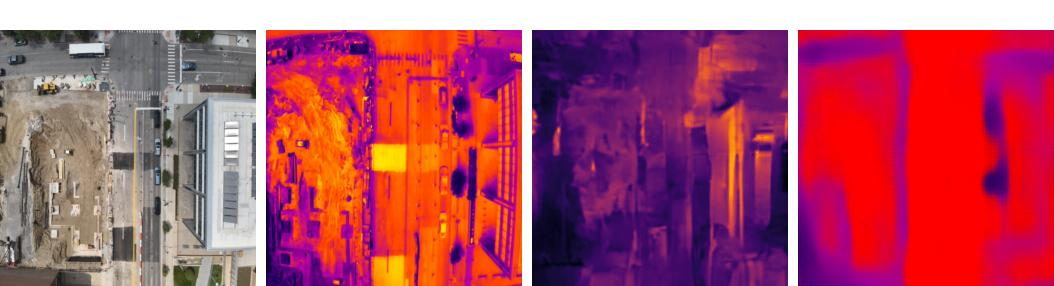

148.JPG:  RGB  |  Ground Truth  |  Baseline  |  Refined v3


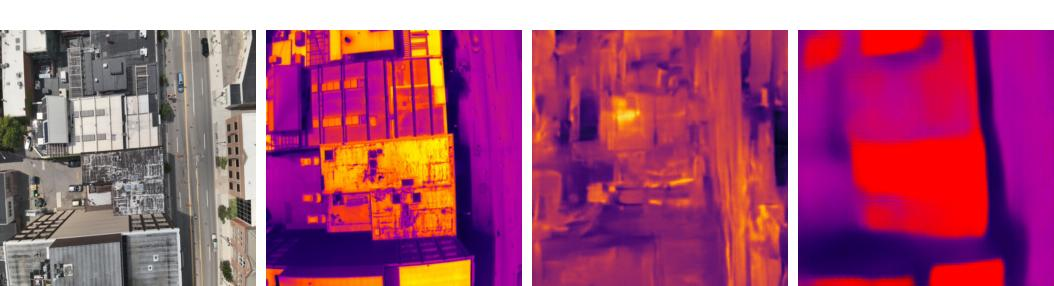

198.JPG:  RGB  |  Ground Truth  |  Baseline  |  Refined v3


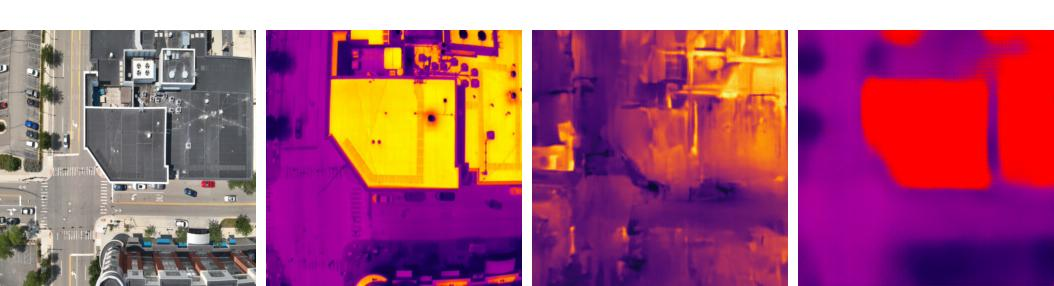

297.JPG:  RGB  |  Ground Truth  |  Baseline  |  Refined v3


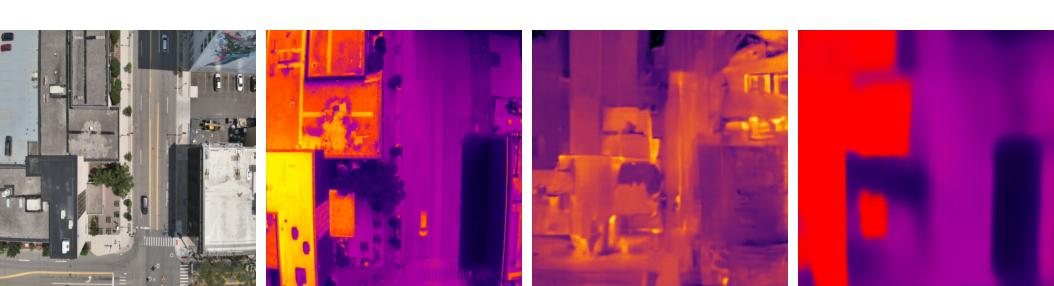

396.JPG:  RGB  |  Ground Truth  |  Baseline  |  Refined v3


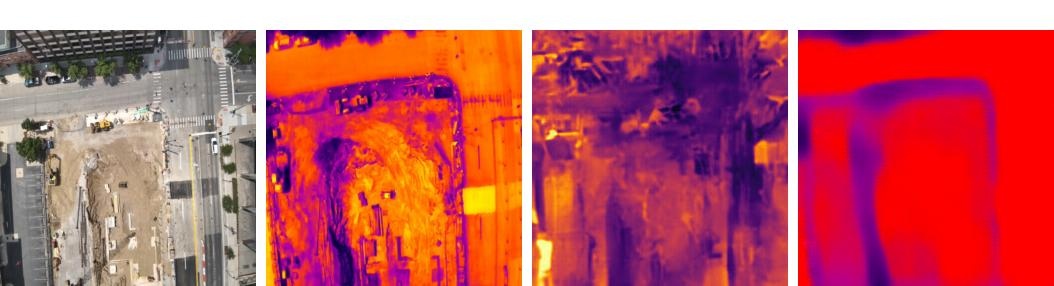

In [11]:
# Visualize 5 samples: RGB | Ground Truth | Baseline (inferno) | Refined v3
vis_dataset = HeatDatasetV3(TRAIN_RGB_DIR, TRAIN_THERMAL_DIR, BASELINE_PRED_TRAIN, augment=False)

sample_indices = [0, 50, 100, 200, 300]

for idx in sample_indices:
    if idx >= len(vis_dataset):
        continue
    rgb, pred_gray, w, a, gt, fname = vis_dataset[idx]
    rgb_dev = rgb.unsqueeze(0).to(device)
    pred_dev = pred_gray.unsqueeze(0).to(device)
    w_dev = w.unsqueeze(0).to(device)
    a_dev = a.unsqueeze(0).to(device)

    with torch.no_grad():
        refined = model(rgb_dev, pred_dev, w_dev, a_dev)
        baseline = apply_inferno_tensor(pred_dev)

    # Convert to PIL
    rgb_pil = to_pil_image(rgb)
    gt_pil = to_pil_image(gt)
    base_pil = to_pil_image(baseline[0].cpu())
    ref_pil = to_pil_image(refined[0].cpu())

    # Stitch
    gap = 10
    combined = Image.new('RGB', (256*4 + gap*3, 256+30), (255,255,255))
    combined.paste(rgb_pil, (0, 30))
    combined.paste(gt_pil, (256+gap, 30))
    combined.paste(base_pil, (512+gap*2, 30))
    combined.paste(ref_pil, (768+gap*3, 30))
    combined.save(str(VIS_DIR / f'compare_{fname}'))

    print(f'{fname}:  RGB  |  Ground Truth  |  Baseline  |  Refined v3')
    display(IPImage(filename=str(VIS_DIR / f'compare_{fname}')))

## Cell 10: Generate Test Predictions (for submission)

In [12]:
# Generate refined predictions for all 202 test images
test_dataset = HeatDatasetV3(TEST_RGB_DIR, None, BASELINE_PRED_TEST, augment=False, is_test=True)
# Copy weather normalization from training
test_dataset.w_mean = eval_dataset.w_mean
test_dataset.w_std = eval_dataset.w_std

test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

print(f'Generating {len(test_dataset)} test predictions...')
count = 0
with torch.no_grad():
    for batch in test_loader:
        rgb, pred_gray, w, a, fnames = batch
        rgb, pred_gray, w, a = rgb.to(device), pred_gray.to(device), w.to(device), a.to(device)

        refined = model(rgb, pred_gray, w, a)

        for i, fname in enumerate(fnames):
            to_pil_image(refined[i].cpu()).save(str(OUTPUT_DIR / fname))
            count += 1
        if count % 40 == 0:
            print(f'  [{count}/{len(test_dataset)}]')

print(f'\nDone! {count} predictions saved to {OUTPUT_DIR}')
print(f'\n★ These are your submission files!')

Generating 202 test predictions...
  [40/202]
  [80/202]
  [120/202]
  [160/202]
  [200/202]

Done! 202 predictions saved to /home/avaithinathanaso/AI_Heat_Resilience_Hackathon_Resources/AI_Heat_Resilience_Hackathon_Resources/ThermalGen/test_predictions_v3

★ These are your submission files!


## Cell 11: Zip for Download

In [13]:
import zipfile

zip_path = THERMAL_GEN_DIR / 'test_predictions_v3.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(os.listdir(OUTPUT_DIR)):
        if f.upper().endswith('.JPG'):
            zf.write(OUTPUT_DIR / f, f)

print(f'Zipped to {zip_path}')
print(f'Size: {os.path.getsize(zip_path) / 1e6:.1f} MB')

from IPython.display import FileLink
FileLink(str(zip_path))

Zipped to /home/avaithinathanaso/AI_Heat_Resilience_Hackathon_Resources/AI_Heat_Resilience_Hackathon_Resources/ThermalGen/test_predictions_v3.zip
Size: 0.8 MB


/home/avaithinathanaso/AI_Heat_Resilience_Hackathon_Resources/AI_Heat_Resilience_Hackathon_Resources/ThermalGen/test_predictions_v3.zip